# Dataset Visualization

Visual inspection of the spike-encoded datasets used by the SNN framework:
1. MNIST after Difference-of-Gaussians (DoG) filtering
2. CIFAR-10 after whitening kernel preprocessing (Falez 2020)

In [7]:
import os

import matplotlib.pyplot as plt
import torch
import torchvision

from spiking.preprocessing import (
    apply_difference_of_gaussians_filter,
    apply_latency_encoding,
    discretize_times,
)
from applications.datasets import MnistDataset

## 1. MNIST after Difference-of-Gaussians

In [8]:
mnist = MnistDataset("../data", "test")
print(f"MNIST test: {len(mnist)} images")
print(f"  inputs shape: {mnist.inputs.shape}")
print(f"  all_times shape: {mnist.all_times.shape}")

MNIST test: 10000 images
  inputs shape: torch.Size([10000, 28, 28])
  all_times shape: torch.Size([10000, 2, 28, 28])


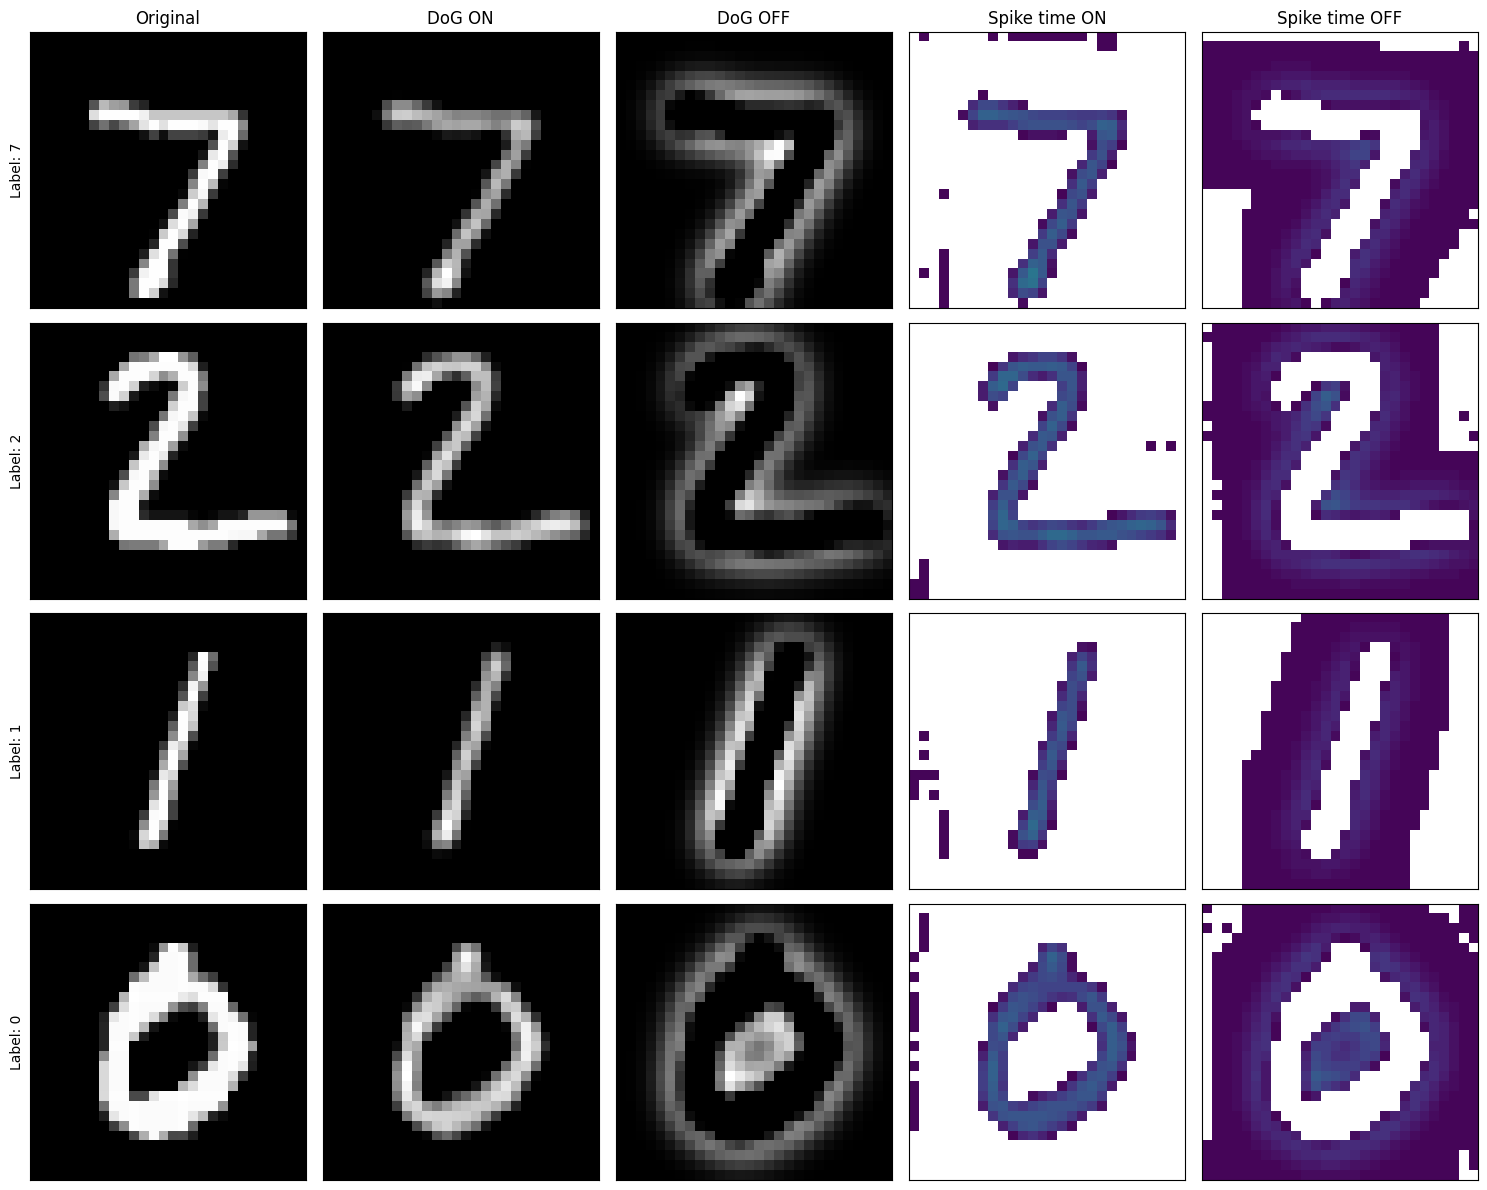

In [9]:
N_SAMPLES = 4

fig, axes = plt.subplots(N_SAMPLES, 5, figsize=(15, 3 * N_SAMPLES))
col_titles = ["Original", "DoG ON", "DoG OFF", "Spike time ON", "Spike time OFF"]

for col, title in enumerate(col_titles):
    axes[0, col].set_title(title)

for row in range(N_SAMPLES):
    img = mnist.inputs[row]
    dog = apply_difference_of_gaussians_filter(img)
    times = mnist.all_times[row]
    label = mnist.outputs[row].item()

    # Replace inf with NaN for display (shows as white)
    times_display = times.clone()
    times_display[~torch.isfinite(times_display)] = float("nan")

    axes[row, 0].imshow(img, cmap="gray")
    axes[row, 0].set_ylabel(f"Label: {label}")
    axes[row, 1].imshow(dog[0], cmap="gray")
    axes[row, 2].imshow(dog[1], cmap="gray")
    axes[row, 3].imshow(times_display[0], cmap="viridis_r", vmin=0, vmax=1)
    axes[row, 4].imshow(times_display[1], cmap="viridis_r", vmin=0, vmax=1)

for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

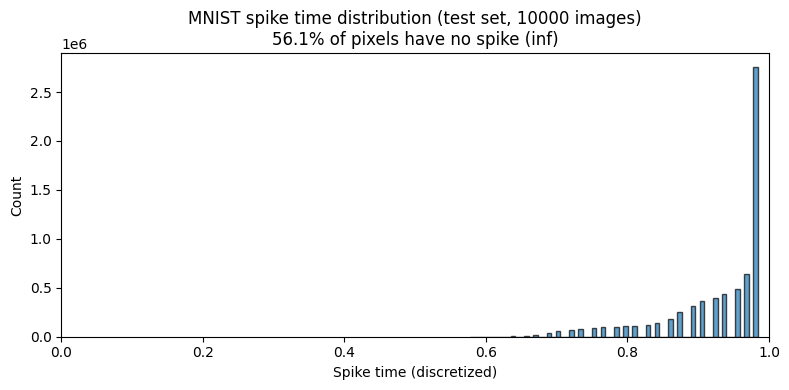

In [10]:
all_times_flat = mnist.all_times.ravel()
finite_times = all_times_flat[torch.isfinite(all_times_flat)]
inf_fraction = 1.0 - len(finite_times) / len(all_times_flat)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(finite_times.numpy(), bins=64, edgecolor="black", alpha=0.7)
ax.set_xlabel("Spike time (discretized)")
ax.set_ylabel("Count")
ax.set_title(
    f"MNIST spike time distribution (test set, {len(mnist)} images)\n"
    f"{inf_fraction:.1%} of pixels have no spike (inf)"
)
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

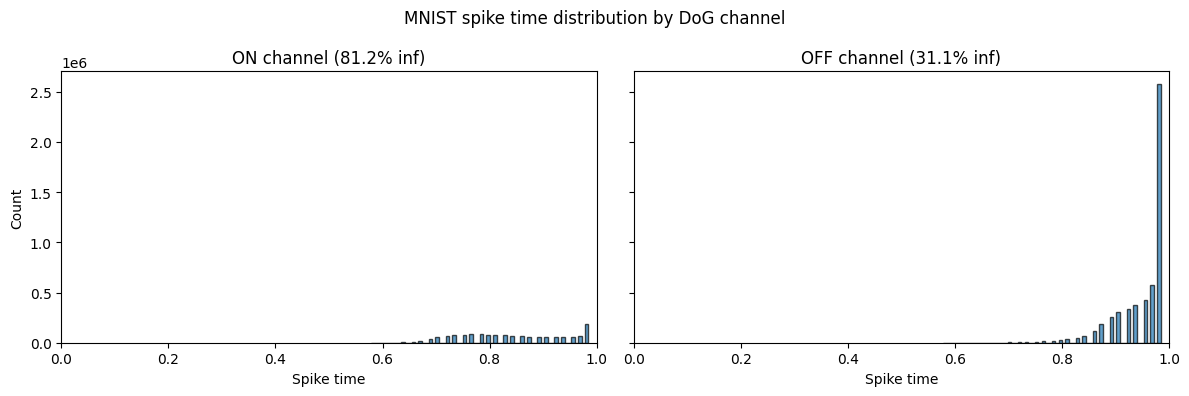

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
channel_names = ["ON", "OFF"]

for ch, (ax, name) in enumerate(zip(axes, channel_names)):
    ch_times = mnist.all_times[:, ch].ravel()
    finite = ch_times[torch.isfinite(ch_times)]
    inf_frac = 1.0 - len(finite) / len(ch_times)
    ax.hist(finite.numpy(), bins=64, edgecolor="black", alpha=0.7)
    ax.set_title(f"{name} channel ({inf_frac:.1%} inf)")
    ax.set_xlabel("Spike time")
    ax.set_xlim(0, 1)

axes[0].set_ylabel("Count")
fig.suptitle("MNIST spike time distribution by DoG channel")
plt.tight_layout()
plt.show()

## 2. CIFAR-10 after Whitening Kernels

In [12]:
# Load raw CIFAR-10 for display alongside whitened versions
cifar_raw = torchvision.datasets.CIFAR10("../data", train=False, download=True)
raw_images = torch.from_numpy(cifar_raw.data).float() / 255.0  # (N, 32, 32, 3)

# Load pre-processed whitened+encoded images
PROCESSED_DIR = "../data/processed-cifar10"
test_data = torch.load(f"{PROCESSED_DIR}/test.pt", weights_only=True)
test_times = test_data["images"]   # (N, 6, 32, 32)
test_labels = test_data["labels"]  # (N,)

print(f"CIFAR-10 test: {len(test_labels)} images")
print(f"  test_times shape: {test_times.shape}")

Files already downloaded and verified
CIFAR-10 test: 10000 images
  test_times shape: torch.Size([10000, 6, 32, 32])


### Whitening kernels and output

Visualize the learned whitening kernels, then the whitened images: combined (RGB+ - RGB- scaled to [0,1]), RGB+ and RGB- channels.

Kernel shape: torch.Size([3, 3, 9, 9])


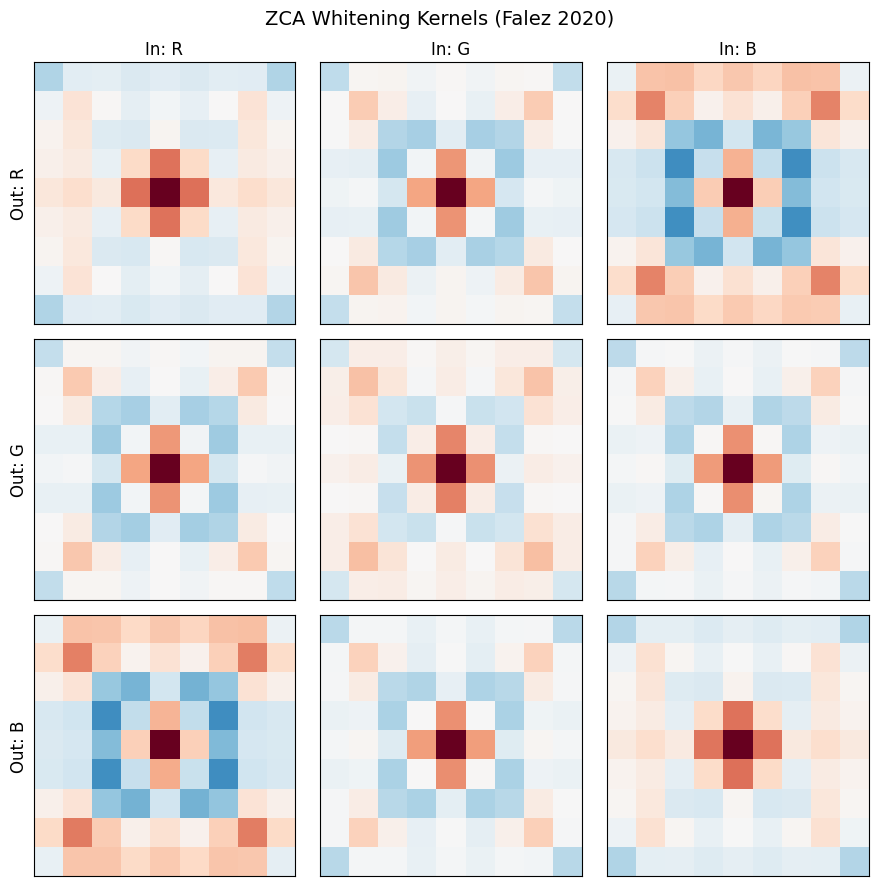

In [13]:
from spiking.preprocessing.whitening_kernels import load_kernels, apply_whitening_kernels, compute_patch_mean

# Load whitening kernels
kernels = load_kernels(f"{PROCESSED_DIR}/kernels.pt")
print(f"Kernel shape: {kernels.shape}")  # (C_out, C_in, kH, kW) = (3, 3, 9, 9)

# Plot kernels: each row = output channel (R, G, B), each col = input channel (R, G, B)
fig, axes = plt.subplots(3, 3, figsize=(9, 9))
ch_labels = ["R", "G", "B"]
for out_ch in range(3):
    for in_ch in range(3):
        k = kernels[out_ch, in_ch].numpy()
        vmax = max(abs(k.min()), abs(k.max()))
        axes[out_ch, in_ch].imshow(k, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
        axes[out_ch, in_ch].set_xticks([])
        axes[out_ch, in_ch].set_yticks([])
        if out_ch == 0:
            axes[out_ch, in_ch].set_title(f"In: {ch_labels[in_ch]}", fontsize=12)
        if in_ch == 0:
            axes[out_ch, in_ch].set_ylabel(f"Out: {ch_labels[out_ch]}", fontsize=12)

plt.suptitle("ZCA Whitening Kernels (Falez 2020)", fontsize=14)
plt.tight_layout()
plt.show()

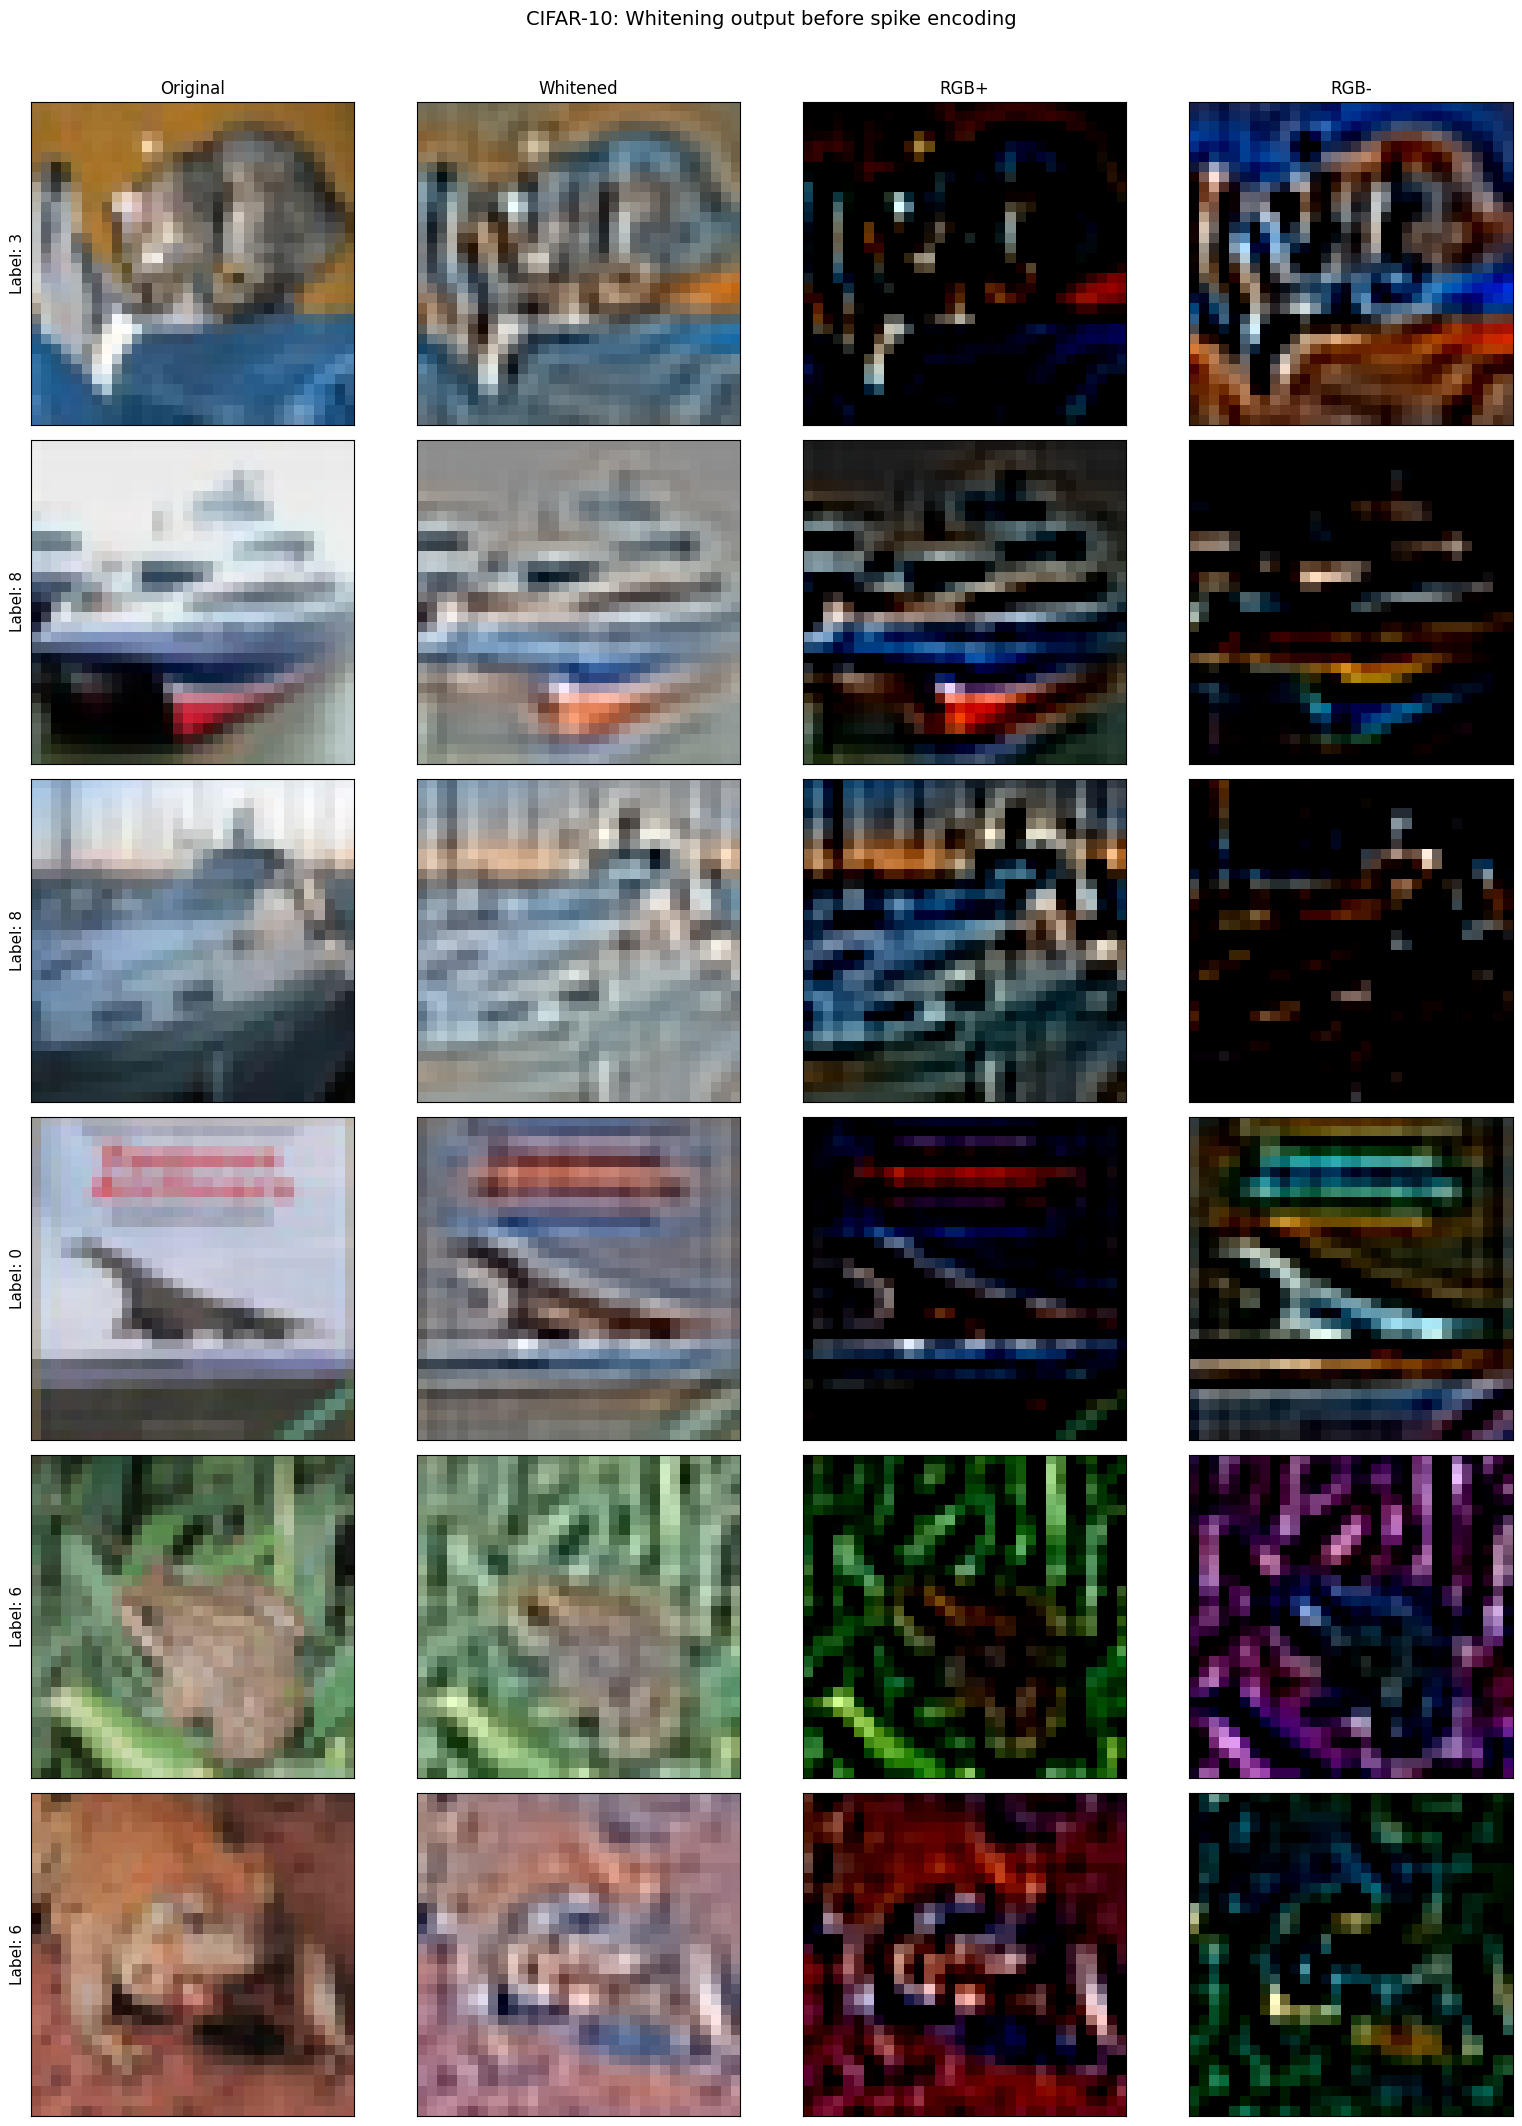

In [20]:
# Apply whitening to raw images
raw_chw = raw_images.permute(0, 3, 1, 2)  # (N, 3, 32, 32)
mean = compute_patch_mean(raw_chw, patch_size=kernels.shape[-1], n_patches=500_000)
whitened = apply_whitening_kernels(raw_chw, kernels, mean)

N_SAMPLES = 6

fig, axes = plt.subplots(N_SAMPLES, 4, figsize=(16, 3.5 * N_SAMPLES))
col_titles = ["Original", "Whitened", "RGB+", "RGB-"]
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=12)

for row in range(N_SAMPLES):
    label = test_labels[row].item()
    w = whitened[row]  # (3, 32, 32)

    # Per-sample min-max scale to [-1, 1] (same as encode_whitened_image)
    mn, mx = w.min(), w.max()
    scaled = 2.0 * (w - mn) / (mx - mn) - 1.0 if mx > mn else w

    pos = scaled.clamp(min=0)   # (3, H, W)
    neg = (-scaled).clamp(min=0)  # (3, H, W)

    # Combined: pos - neg is back to scaled [-1, 1], shift to [0, 1] for display
    combined = ((pos - neg) + 1.0) / 2.0  # [-1,1] -> [0,1]

    axes[row, 0].imshow(raw_images[row])
    axes[row, 0].set_ylabel(f"Label: {label}", fontsize=11)
    axes[row, 1].imshow(combined.permute(1, 2, 0).clamp(0, 1).numpy())
    axes[row, 2].imshow(pos.permute(1, 2, 0).numpy())
    axes[row, 3].imshow(neg.permute(1, 2, 0).numpy())

for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("CIFAR-10: Whitening output before spike encoding", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

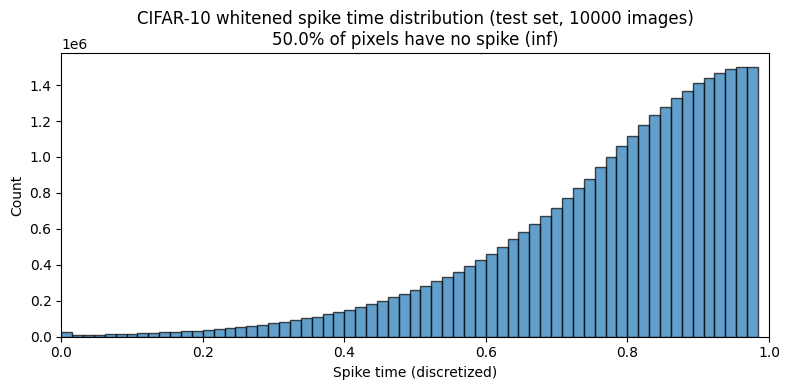

In [22]:
all_times_flat = test_times.ravel()
finite_times = all_times_flat[torch.isfinite(all_times_flat)]
inf_fraction = 1.0 - len(finite_times) / len(all_times_flat)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(finite_times.numpy(), bins=64, edgecolor="black", alpha=0.7)
ax.set_xlabel("Spike time (discretized)")
ax.set_ylabel("Count")
ax.set_title(
    f"CIFAR-10 whitened spike time distribution (test set, {len(test_labels)} images)\n"
    f"{inf_fraction:.1%} of pixels have no spike (inf)"
)
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

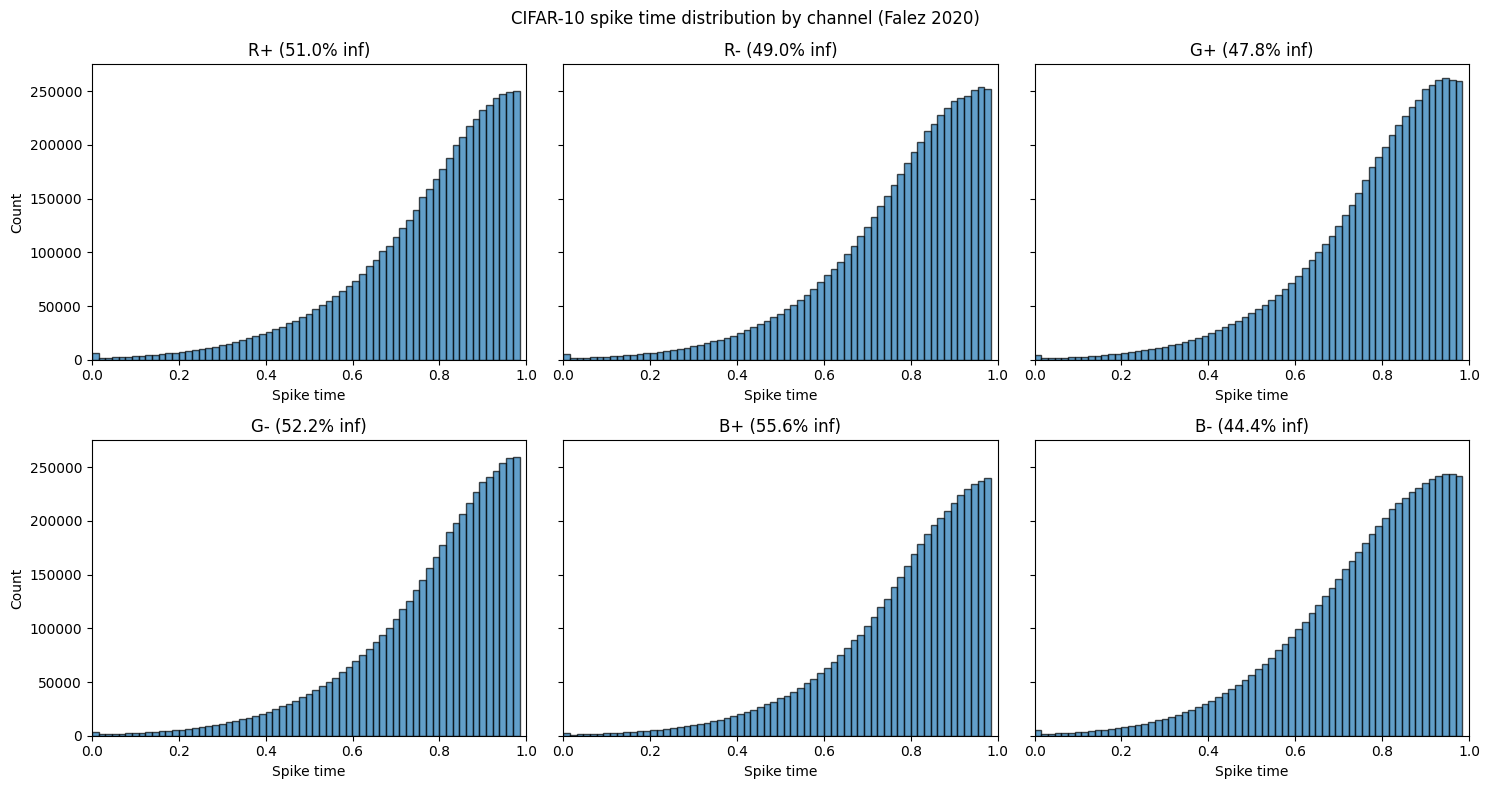

In [23]:
CHANNEL_NAMES = ["R+", "R-", "G+", "G-", "B+", "B-"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)

for ch, (ax, name) in enumerate(zip(axes.ravel(), CHANNEL_NAMES)):
    ch_times = test_times[:, ch].ravel()
    finite = ch_times[torch.isfinite(ch_times)]
    inf_frac = 1.0 - len(finite) / len(ch_times)
    ax.hist(finite.numpy(), bins=64, edgecolor="black", alpha=0.7)
    ax.set_title(f"{name} ({inf_frac:.1%} inf)")
    ax.set_xlabel("Spike time")
    ax.set_xlim(0, 1)

axes[0, 0].set_ylabel("Count")
axes[1, 0].set_ylabel("Count")
fig.suptitle("CIFAR-10 spike time distribution by channel (Falez 2020)")
plt.tight_layout()
plt.show()